# Identity Form: Effect of $\alpha$ on Clustering

The identity form (Lemma 3.1 with $K = \alpha I$) uses $\alpha$ both at **training time**
(in the loss gradient) and at **test time** (in the similarity function):

$$p_{ij} = \prod_d \frac{1}{\sqrt{1 + v_d/\alpha}}\,\exp\!\Bigl(-\frac{\delta_d^2}{2(v_d + \alpha)}\Bigr)$$

The gradient of $\log p$ for positive pairs is (note: this is $\partial \log p / \partial v_d$, not the loss gradient $\partial \mathcal{L}/\partial v_d$; since $\mathcal{L} = -\log p$, the loss gradient has the opposite sign):

$$\frac{\partial \log p}{\partial v_d} \propto -\frac{1 - \delta_d^2/(v_d + \alpha)}{v_d + \alpha}$$

When $\delta_d^2 > v_d + \alpha$, the gradient is positive (increase variance).
The threshold $v_d + \alpha$ determines which dimensions get high variance.
**Different $\alpha$ values produce different learned variances.**

| $\alpha$ regime | Training effect | Test-time similarity |
|---|---|---|
| Large $\alpha$ | Denominator dominates $\Rightarrow$ variance freely grows $\Rightarrow$ large variances | Variance nearly ignored |
| Moderate $\alpha$ | Balanced threshold → moderate variances | Variance modulates similarity |
| Small $\alpha$ | Tight regularization $\Rightarrow$ variance stays small | Log-normalizer dominates |

This notebook trains a **separate UG identity model for each $\alpha$** and
compares clustering quality, variance distributions, and selective prediction.

## Setup

In [6]:
import sys, os, csv, tempfile, json
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from embedders.nonlinear import NonLinearEmbedder, set_seed
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase
from embedders.base import EmbeddingResult
from datasets.paired_reads import PairedReadsDataset
from clustering.kmedoid import KMedoidClusterer
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
    compute_class_center_medium_similarity,
)
import sklearn.metrics

SEED = 26042024
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_TSV = '../../data/dnabert/eval/reference/clustering_0.tsv'
TRAIN_FRAC = 0.7
MODEL_DIR = '../../models/notebook'

print(f'Device: {DEVICE}')

Device: cuda


## Data Loading

In [7]:
csv.field_size_limit(min(sys.maxsize, 2**31 - 1))
with open(DATA_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    header = next(reader)
    all_rows = list(reader)

sequences = [r[0] for r in all_rows]
labels_str = [r[1] for r in all_rows]
unique_labels = sorted(set(labels_str))

rng = np.random.RandomState(SEED)
species_to_idx = defaultdict(list)
for i, lab in enumerate(labels_str):
    species_to_idx[lab].append(i)

train_idx, test_idx = [], []
for lab in unique_labels:
    idxs = np.array(species_to_idx[lab])
    rng.shuffle(idxs)
    split = int(len(idxs) * TRAIN_FRAC)
    train_idx.extend(idxs[:split].tolist())
    test_idx.extend(idxs[split:].tolist())

train_seqs = [sequences[i] for i in train_idx]
train_labels = [labels_str[i] for i in train_idx]
test_seqs = [sequences[i] for i in test_idx]
test_labels_str = [labels_str[i] for i in test_idx]

lab2id = {l: i for i, l in enumerate(unique_labels)}
train_labels_num = np.array([lab2id[l] for l in train_labels])
test_labels = np.array([lab2id[l] for l in test_labels_str])
n_species = len(unique_labels)

# Build contrastive pairs for variance training
# Write plain text (seq1,seq2 per line) — PairedReadsDataset uses line.split(",")
train_by_species = defaultdict(list)
for seq, lab in zip(train_seqs, train_labels):
    train_by_species[lab].append(seq)

train_csv_path = os.path.join(tempfile.gettempdir(), 'genome_train_pairs.csv')
n_pairs = 0
with open(train_csv_path, 'w') as f:
    for lab in unique_labels:
        seqs = train_by_species[lab]
        for i in range(0, len(seqs) - 1, 2):
            f.write(f'{seqs[i]},{seqs[i + 1]}\n')
            n_pairs += 1

print(f'Total: {len(sequences)} sequences, {n_species} species')
print(f'Train: {len(train_seqs)}, Test: {len(test_seqs)}, Pairs: {n_pairs}')

Total: 20000 sequences, 200 species
Train: 14000, Test: 6000, Pairs: 7000


## Load NonLinear Baseline

The mean network is shared across all models. Each $\alpha$ variant copies
this mean network and trains its own variance network.

In [8]:
set_seed(SEED)

model_nl = NonLinearEmbedder.load(os.path.join(MODEL_DIR, 'nonlinear.model'), device=DEVICE)
print(f'NonLinear loaded')

train_emb_nl = model_nl.embed(train_seqs)
test_emb_nl = model_nl.embed(test_seqs)
print(f'Embeddings: train {train_emb_nl.mean.shape}, test {test_emb_nl.mean.shape}')

NonLinear loaded
Embeddings: train (14000, 256), test (6000, 256)


## NonLinear Baseline (deterministic)

Compute the deterministic L2 clustering as the reference point.
This is what $\alpha \to \infty$ converges to (variance fully ignored).

In [9]:
METRIC = 'l2'
MIN_BIN_SIZE = 5
KMEDOID_METHOD = 'alternate'

pv_nl, scale_nl = compute_class_center_medium_similarity(
    train_emb_nl.point_estimate, train_labels_num, metric=METRIC)
threshold_nl = pv_nl[-3]
kmed_nl = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                            scale=scale_nl, method=KMEDOID_METHOD)
pred_nl = kmed_nl.fit_predict(test_emb_nl, min_similarity=threshold_nl)
r_nl = count_high_quality_clusters(test_labels, pred_nl)
k_nl = len(set(pred_nl[pred_nl != -1].tolist()))
assigned_nl = (pred_nl != -1).sum()

print(f'NonLinear: k={k_nl}, assigned={assigned_nl}/{len(test_labels)}, '
      f'F1>0.5={r_nl["counts"][4]}, F1>0.7={r_nl["counts"][6]}')

Auto-calibrated scale: 2.997387 (median raw distance: 0.2313)
Percentile values: [0.12450093482649371, 0.2280380439922255, 0.3230909830239522, 0.41105853727277486, 0.5000850313731194, 0.5835276401654267, 0.6581730939166871, 0.73087140859097, 0.8041553183219755]
KMedoids: k_est=123, n=6000, method=alternate
NonLinear: k=121, assigned=5993/6000, F1>0.5=40, F1>0.7=18


## Train & Evaluate per $\alpha$

For each $\alpha$ we:
1. **Train** a new UG identity model (copy mean from NonLinear, train variance with that $\alpha$)
2. **Embed** train and test sets
3. **Cluster** using identity form similarity with the same $\alpha$
4. **Evaluate** clustering quality

Models are cached to disk — re-running skips training if the model file exists.

In [10]:
alphas = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]

METRIC = 'l2'
MIN_BIN_SIZE = 5
KMEDOID_METHOD = 'alternate'

sweep_results = {}

for alpha in alphas:
    tag = f'{alpha:.4f}'.rstrip('0').rstrip('.')
    model_path = os.path.join(MODEL_DIR, f'uncertaingen_identity_a{tag}.model')
    loss_path = os.path.join(MODEL_DIR, f'uncertaingen_identity_a{tag}_loss.json')

    # --- Train or load ---
    if os.path.exists(model_path):
        model = UncertainGenEmbedder.load(model_path, device=DEVICE)
        loss_hist = json.load(open(loss_path)) if os.path.exists(loss_path) else []
        print(f'\nalpha={alpha:7.2f}  Loaded from {model_path} ({len(loss_hist)} epochs)')
    else:
        set_seed(SEED)
        model = UncertainGenEmbedder(
            k=4, dim=256, k_form='identity', alpha=alpha,
            device=DEVICE, seed=SEED,
        )
        model.copy_mean_from(model_nl)

        dataset = PairedReadsDataset(
            file_path=train_csv_path,
            transform_func=model._feature_extractor.extract,
            neg_sample_per_pos=20, max_read_num=0, seed=SEED,
        )
        print(f'\nalpha={alpha:7.2f}  Training variance network...')
        loss_hist = train_variance_phase(
            model=model, dataset=dataset,
            lr=0.0001, epochs=100, batch_size=256, device=DEVICE,
            num_workers=0, alpha=alpha, verbose=False,
        )
        model.save(model_path)
        with open(loss_path, 'w') as f:
            json.dump(loss_hist, f)
        print(f'  Saved -> {model_path}  (final loss: {loss_hist[-1]:.4f})')

    # --- Embed ---
    train_emb = model.embed(train_seqs)
    test_emb = model.embed(test_seqs)

    # --- Variance stats ---
    v = test_emb.variance
    var_mean = float(v.mean())
    var_std = float(v.std())

    # --- Cluster ---
    pv, sc = compute_class_center_medium_similarity(
        train_emb.point_estimate, train_labels_num, metric=METRIC,
        variances=train_emb.variance, k_form='identity', alpha=alpha)
    threshold = pv[-3]

    kmed = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                             scale=sc, method=KMEDOID_METHOD,
                             k_form='identity', alpha=alpha)
    pred = kmed.fit_predict(test_emb, min_similarity=threshold)
    r = count_high_quality_clusters(test_labels, pred)
    k = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    coverage = assigned / len(test_labels)

    sweep_results[alpha] = {
        'model': model, 'pred': pred, 'r': r, 'k': k,
        'assigned': assigned, 'coverage': coverage,
        'scale': sc, 'threshold': threshold, 'percentiles': pv,
        'loss_hist': loss_hist, 'var_mean': var_mean, 'var_std': var_std,
        'test_emb': test_emb,
    }
    print(f'  var: mean={var_mean:.6f} std={var_std:.6f}  '
          f'k={k:4d}  assigned={assigned:5d} ({coverage:.1%})  '
          f'F1>0.5={r["counts"][4]:3d}  F1>0.7={r["counts"][6]:3d}')


alpha=   0.01  Loaded from ../models/notebook\uncertaingen_identity_a0.01.model (100 epochs)
Auto-calibrated scale: 0.067348 (median raw distance: 10.2921)
Percentile values: [0.34657225012779236, 0.39751702547073364, 0.43158257007598877, 0.4630346894264221, 0.5000057816505432, 0.541481614112854, 0.5782696008682251, 0.6136783957481384, 0.6538125276565552]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:21<00:00]


KMedoids: k_est=72, n=6000, method=alternate
  var: mean=0.000820 std=0.005535  k=  72  assigned= 6000 (100.0%)  F1>0.5=  9  F1>0.7=  2

alpha=   0.05  Loaded from ../models/notebook\uncertaingen_identity_a0.05.model (100 epochs)
Auto-calibrated scale: 0.236108 (median raw distance: 2.9357)
Percentile values: [0.2191578894853592, 0.29598546028137207, 0.35957610607147217, 0.4243695139884949, 0.5000155568122864, 0.5819888710975647, 0.6538484692573547, 0.7202959656715393, 0.7879367470741272]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:22<00:00]


KMedoids: k_est=93, n=6000, method=alternate
  var: mean=0.000316 std=0.003292  k=  90  assigned= 5989 (99.8%)  F1>0.5= 13  F1>0.7=  2

alpha=   0.10  Loaded from ../models/notebook\uncertaingen_identity_a0.1.model (100 epochs)
Auto-calibrated scale: 0.589818 (median raw distance: 1.1752)
Percentile values: [0.12754295766353607, 0.23110540211200714, 0.32564014196395874, 0.4123725891113281, 0.5000592470169067, 0.5821887254714966, 0.6552952527999878, 0.7261976003646851, 0.7981945276260376]


...

KMedoids: k_est=1, n=6000, method=alternate
  var: mean=0.579209 std=0.112696  k=   1  assigned= 6000 (100.0%)  F1>0.5=  0  F1>0.7=  0


 Counting lines │██████████████████████████████│ 140M/140M [00:00<00:00]
 Loading read pairs │██████████████████████████████│ 7000/7000 [00:45<00:00]


Dataset loaded: 7000 read pairs from 7000 total lines.

alpha= 100.00  Training variance network...
  Saved -> ../models/notebook\uncertaingen_identity_a100.model  (final loss: 0.1896)
Auto-calibrated scale: 0.231124 (median raw distance: 2.9990)
Percentile values: [0.495304137468338, 0.49643251299858093, 0.49757254123687744, 0.4987836182117462, 0.5000001192092896, 0.5011672377586365, 0.5022398829460144, 0.5034099221229553, 0.5049344897270203]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:47<00:00]


KMedoids: k_est=1, n=6000, method=alternate
  var: mean=1.184777 std=0.141687  k=   1  assigned= 6000 (100.0%)  F1>0.5=  0  F1>0.7=  0


## Results

### Learned Variance vs $\alpha$

The identity form gradient has a threshold: variance increases only when $\delta_d^2 > v_d + \alpha$.
However, the data reveals a more nuanced picture than the threshold alone would suggest.
While larger $\alpha$ raises this threshold, the gradient magnitude is also scaled by $1/(v_d + \alpha)$,
which weakens the corrective signal and allows variance to drift upward at large $\alpha$.
In practice, small $\alpha$ tightly constrains variance while large $\alpha$ lets it grow freely.
This plot shows the non-monotonic (U-shaped) relationship between learned variance and $\alpha$.

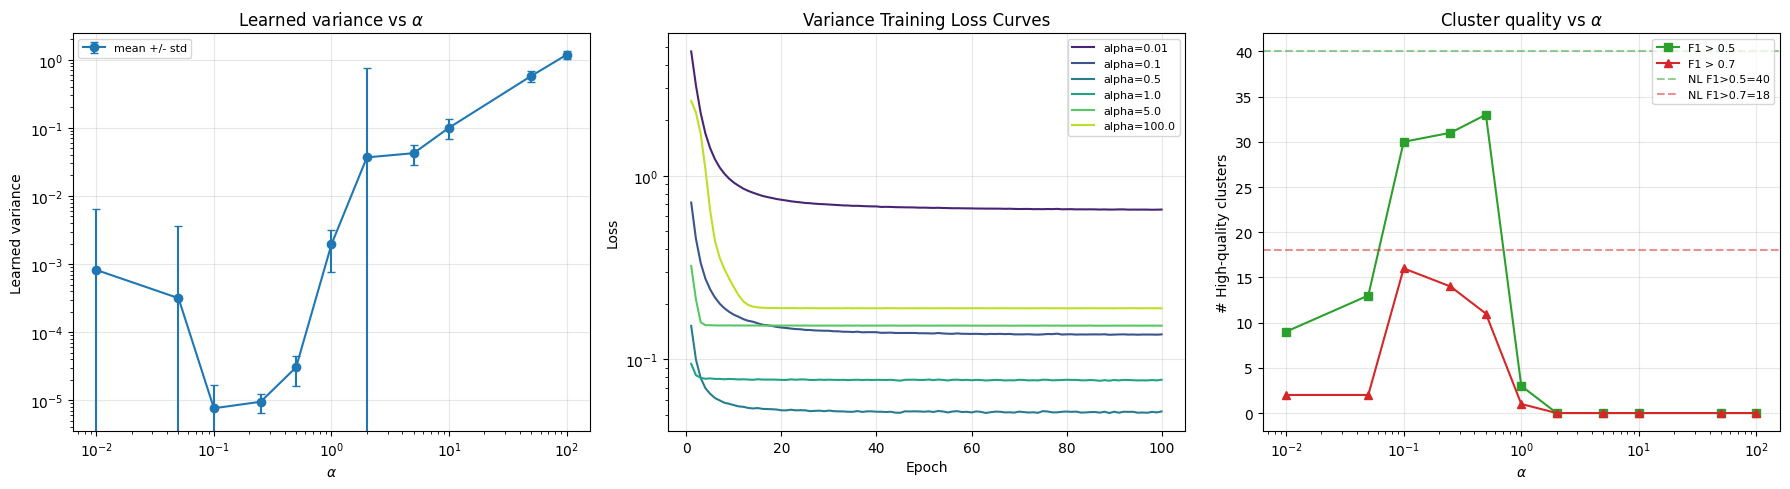

   alpha    var_mean     var_std      k  F1>0.5  F1>0.7   cover
-----------------------------------------------------------------
    0.01    0.000820    0.005535     72       9       2  100.0%
    0.05    0.000316    0.003292     90      13       2   99.8%
    0.10    0.000008    0.000009    121      30      16   99.8%
    0.25    0.000010    0.000003    123      31      14   99.9%
    0.50    0.000031    0.000014    119      33      11  100.0%
    1.00    0.001952    0.001176     42       3       1  100.0%
    2.00    0.036875    0.714060      4       0       0  100.0%
    5.00    0.042505    0.014270      4       0       0  100.0%
   10.00    0.100586    0.033088      3       0       0  100.0%
   50.00    0.579209    0.112696      1       0       0  100.0%
  100.00    1.184777    0.141687      1       0       0  100.0%
     inf          --          --    121      40      18   99.9%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

a_vals = sorted(sweep_results.keys())
var_means = [sweep_results[a]['var_mean'] for a in a_vals]
var_stds = [sweep_results[a]['var_std'] for a in a_vals]
k_vals = [sweep_results[a]['k'] for a in a_vals]
f1_05 = [sweep_results[a]['r']['counts'][4] for a in a_vals]
f1_07 = [sweep_results[a]['r']['counts'][6] for a in a_vals]
cov_vals = [sweep_results[a]['coverage'] for a in a_vals]

# Variance vs alpha
ax = axes[0]
ax.errorbar(a_vals, var_means, yerr=var_stds, fmt='o-', color='tab:blue',
            capsize=3, label='mean +/- std')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('Learned variance')
ax.set_title(r'Learned variance vs $\alpha$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Loss curves
ax = axes[1]
show_alphas_loss = [0.01, 0.1, 0.5, 1.0, 5.0, 100.0]
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(show_alphas_loss)))
for alpha, color in zip(show_alphas_loss, cmap):
    lh = sweep_results[alpha]['loss_hist']
    if lh:
        ax.plot(range(1, len(lh) + 1), lh, '-', color=color, label=f'alpha={alpha}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Variance Training Loss Curves')
ax.legend(fontsize=8)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# F1 vs alpha
ax = axes[2]
ax.semilogx(a_vals, f1_05, 's-', color='tab:green', label='F1 > 0.5')
ax.semilogx(a_vals, f1_07, '^-', color='tab:red', label='F1 > 0.7')
ax.axhline(r_nl['counts'][4], ls='--', color='tab:green', alpha=0.5,
           label=f'NL F1>0.5={r_nl["counts"][4]}')
ax.axhline(r_nl['counts'][6], ls='--', color='tab:red', alpha=0.5,
           label=f'NL F1>0.7={r_nl["counts"][6]}')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('# High-quality clusters')
ax.set_title(r'Cluster quality vs $\alpha$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print(f'{"alpha":>8s}  {"var_mean":>10s}  {"var_std":>10s}  {"k":>5s}  '
      f'{"F1>0.5":>6s}  {"F1>0.7":>6s}  {"cover":>6s}')
print('-' * 65)
for a in a_vals:
    s = sweep_results[a]
    print(f'{a:8.2f}  {s["var_mean"]:10.6f}  {s["var_std"]:10.6f}  {s["k"]:5d}  '
          f'{s["r"]["counts"][4]:6d}  {s["r"]["counts"][6]:6d}  {s["coverage"]:6.1%}')
print(f'{"inf":>8s}  {"--":>10s}  {"--":>10s}  {k_nl:5d}  '
      f'{r_nl["counts"][4]:6d}  {r_nl["counts"][6]:6d}  {assigned_nl/len(test_labels):6.1%}')

**Observation: non-monotonic (U-shaped) variance vs $\alpha$.**
The learned variance does not increase monotonically with $\alpha$. Instead:

- From $\alpha = 0.01$ to $\alpha = 0.1$, mean variance *decreases* (0.000820 $\to$ 0.000008),
  reaching its minimum around $\alpha \in [0.1, 0.25]$.
- From $\alpha = 0.25$ onward, variance *increases dramatically* (0.000010 $\to$ 1.184777 at $\alpha=100$).

This U-shape arises from two competing effects of $\alpha$:
1. **Threshold effect:** larger $\alpha$ raises the threshold $\delta_d^2 > v_d + \alpha$,
   making it harder for the gradient to push variance up. This dominates at small $\alpha$.
2. **Denominator effect:** the gradient magnitude is scaled by $1/(v_d + \alpha)$.
   When $\alpha$ is large, the gradient becomes very flat, so the network can drift to
   large $v_d$ without strong corrective signal. This dominates at large $\alpha$.

The best clustering ($\approx 0.1$--$0.5$) coincides with the variance minimum,
where the model learns small, informative per-dimension variances rather than collapsing
to near-zero or blowing up.

### Clustering: $k$ Estimation and Coverage vs $\alpha$

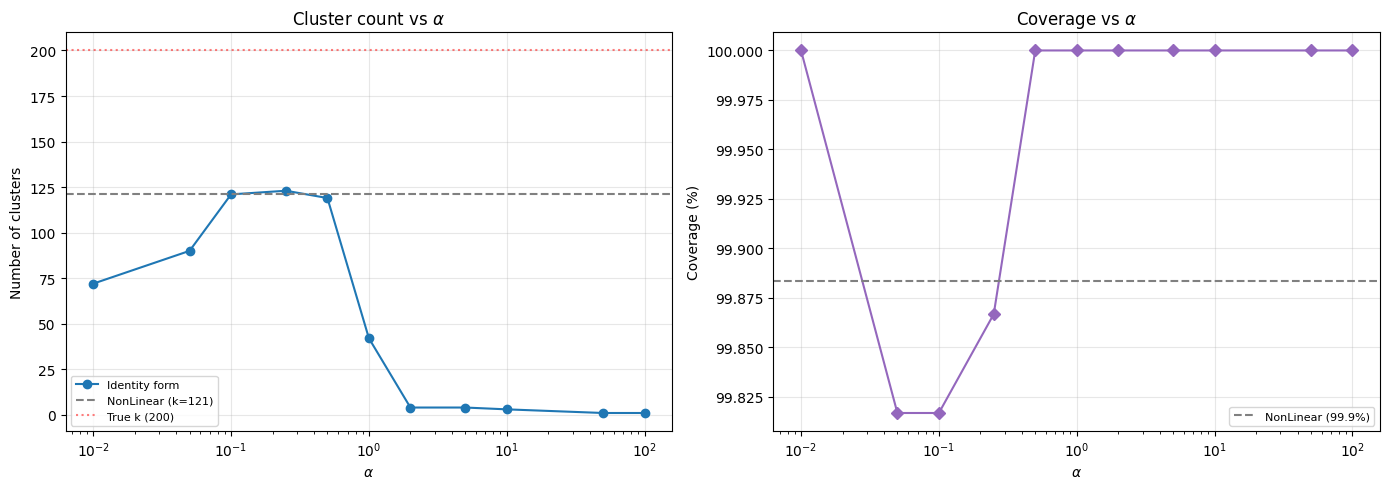

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# k vs alpha
ax = axes[0]
ax.semilogx(a_vals, k_vals, 'o-', color='tab:blue', label='Identity form')
ax.axhline(k_nl, ls='--', color='gray', label=f'NonLinear (k={k_nl})')
ax.axhline(n_species, ls=':', color='red', alpha=0.5, label=f'True k ({n_species})')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('Number of clusters')
ax.set_title(r'Cluster count vs $\alpha$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Coverage vs alpha
ax = axes[1]
ax.semilogx(a_vals, [c * 100 for c in cov_vals], 'D-', color='tab:purple')
ax.axhline(assigned_nl / len(test_labels) * 100, ls='--', color='gray',
           label=f'NonLinear ({assigned_nl/len(test_labels):.1%})')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('Coverage (%)')
ax.set_title(r'Coverage vs $\alpha$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### F1 Threshold Curves

Full F1 threshold curves for a selection of $\alpha$ values.
Each curve uses a model **trained** with that specific $\alpha$.

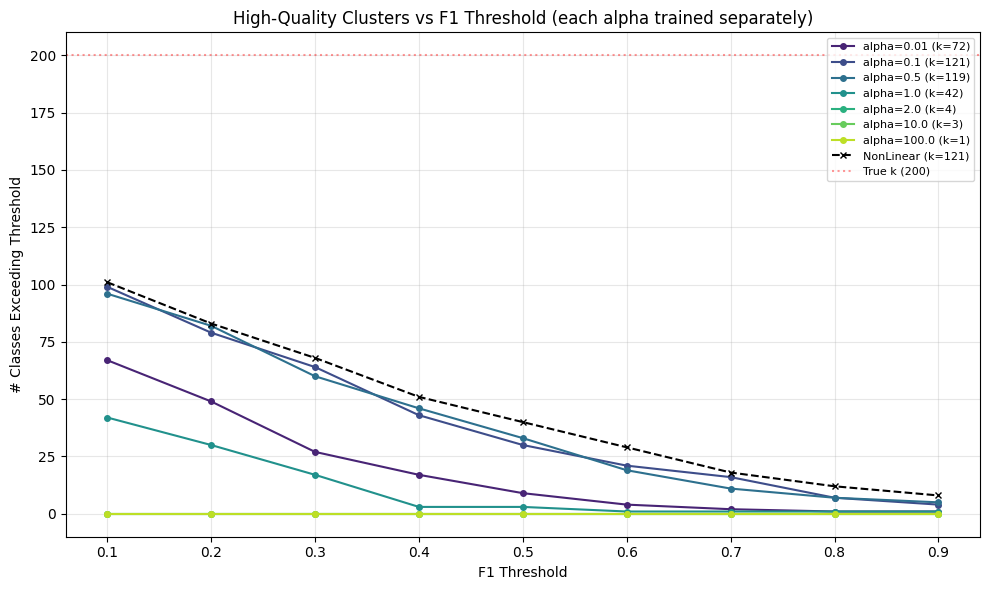

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

thresholds = r_nl['thresholds']
show_alphas = [0.01, 0.1, 0.5, 1.0, 2.0, 10.0, 100.0]
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(show_alphas)))

for alpha, color in zip(show_alphas, cmap):
    r = sweep_results[alpha]['r']
    k = sweep_results[alpha]['k']
    ax.plot(thresholds, r['counts'], 'o-', color=color, markersize=4,
            label=f'alpha={alpha} (k={k})')

ax.plot(thresholds, r_nl['counts'], 'x--', color='black', markersize=5,
        label=f'NonLinear (k={k_nl})')
ax.axhline(n_species, ls=':', color='red', alpha=0.4, label=f'True k ({n_species})')

ax.set_xlabel('F1 Threshold')
ax.set_ylabel('# Classes Exceeding Threshold')
ax.set_title('High-Quality Clusters vs F1 Threshold (each alpha trained separately)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Selective Prediction

Each $\alpha$ produces a different variance field. We compare how well each
model's variance works as a rejection signal (selective prediction).
All models use the **same** NonLinear clustering — only the uncertainty
signal varies.

**Question:** Does the $\alpha$ that produces the best clustering also produce
the best uncertainty for selective prediction? Or are these two objectives
decoupled?

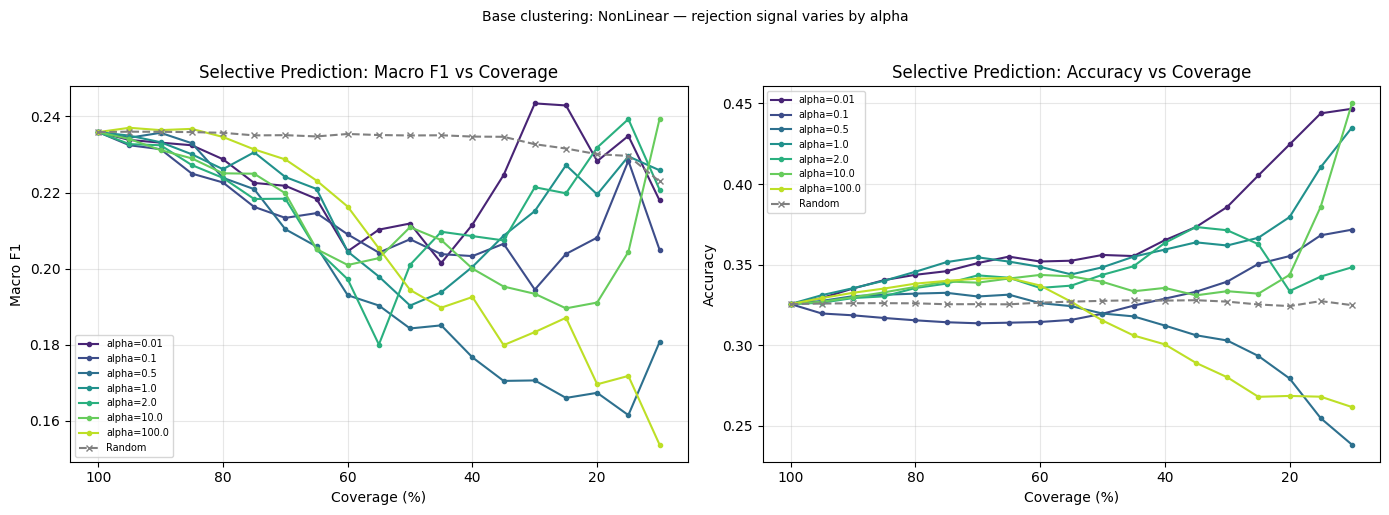

   alpha  F1@100%  F1@80%  F1@60%  F1@40%  |  Acc@100%  Acc@80%  Acc@60%  Acc@40%
---------------------------------------------------------------------------
    0.01   0.236   0.229   0.205   0.212  |   0.326   0.344   0.352   0.365
    0.10   0.236   0.223   0.209   0.203  |   0.326   0.315   0.314   0.329
    0.50   0.236   0.224   0.193   0.177  |   0.326   0.332   0.326   0.312
    1.00   0.236   0.226   0.204   0.200  |   0.326   0.346   0.349   0.359
    2.00   0.236   0.224   0.197   0.209  |   0.326   0.335   0.336   0.363
   10.00   0.236   0.225   0.201   0.200  |   0.326   0.336   0.344   0.336
  100.00   0.236   0.235   0.216   0.193  |   0.326   0.338   0.337   0.301


In [14]:
def selective_curves_fixed(true_labels, pred_labels, uncertainties, coverages, alignment):
    n = len(true_labels)
    order = np.argsort(uncertainties)
    f1_scores, acc_scores = [], []
    for cov in coverages:
        k = max(1, int(n * cov))
        keep = order[:k]
        tl, pl = true_labels[keep], pred_labels[keep]
        mask = pl != -1
        if mask.sum() < 2:
            f1_scores.append(0.0); acc_scores.append(0.0)
            continue
        tl_m, pl_m = tl[mask], pl[mask]
        aligned = np.array([alignment.get(p, -1) for p in pl_m])
        per_f1 = sklearn.metrics.f1_score(tl_m, aligned, average=None, zero_division=0)
        f1_scores.append(np.mean(per_f1))
        acc_scores.append(np.mean(aligned == tl_m))
    return np.array(f1_scores), np.array(acc_scores)

# Use NonLinear clustering as fixed base
mask_base = pred_nl != -1
base_alignment = align_labels_via_hungarian_algorithm(test_labels[mask_base], pred_nl[mask_base])
coverages_d = np.linspace(1.0, 0.1, 19)

# Compute selective curves for each alpha
sel_results = {}
for alpha in show_alphas:
    unc = sweep_results[alpha]['test_emb'].variance.mean(axis=1)
    f1_c, acc_c = selective_curves_fixed(
        test_labels, pred_nl, unc, coverages_d, base_alignment)
    sel_results[alpha] = (f1_c, acc_c)

# Random baseline
rng_d = np.random.RandomState(SEED)
rand_f1, rand_acc = [], []
for _ in range(20):
    rand_unc = rng_d.rand(len(test_labels))
    f1_r, acc_r = selective_curves_fixed(
        test_labels, pred_nl, rand_unc, coverages_d, base_alignment)
    rand_f1.append(f1_r); rand_acc.append(acc_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha, color in zip(show_alphas, cmap):
    f1_c, acc_c = sel_results[alpha]
    axes[0].plot(coverages_d * 100, f1_c, 'o-', color=color,
                 label=f'alpha={alpha}', markersize=3)
    axes[1].plot(coverages_d * 100, acc_c, 'o-', color=color,
                 label=f'alpha={alpha}', markersize=3)

axes[0].plot(coverages_d * 100, np.mean(rand_f1, axis=0), 'x--', color='gray',
             label='Random', markersize=4)
axes[1].plot(coverages_d * 100, np.mean(rand_acc, axis=0), 'x--', color='gray',
             label='Random', markersize=4)

for ax, ylabel, title in zip(axes, ['Macro F1', 'Accuracy'],
        ['Macro F1 vs Coverage', 'Accuracy vs Coverage']):
    ax.set_xlabel('Coverage (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Selective Prediction: {title}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

plt.suptitle('Base clustering: NonLinear — rejection signal varies by alpha',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# Summary table at key coverages
key_covs = [100, 80, 60, 40]
idx = {round(c * 100): i for i, c in enumerate(coverages_d)}
print(f'{"alpha":>8s}  ' + '  '.join(f'F1@{c}%' for c in key_covs)
      + '  |  ' + '  '.join(f'Acc@{c}%' for c in key_covs))
print('-' * 75)
for alpha in show_alphas:
    f1_c, acc_c = sel_results[alpha]
    f1_v = '  '.join(f'{f1_c[idx[c]]:6.3f}' for c in key_covs)
    acc_v = '  '.join(f'{acc_c[idx[c]]:6.3f}' for c in key_covs)
    print(f'{alpha:8.2f}  {f1_v}  |  {acc_v}')

**Answer:** The selective prediction results show that the choice of $\alpha$ has
only a modest effect on uncertainty-based rejection quality. Key findings:

- At full coverage (100%), all models match the NonLinear baseline (F1 = 0.236, Acc = 0.326)
  since the base clustering is identical.
- As coverage decreases, all $\alpha$ values improve only marginally over the random baseline.
  The best gains appear at low coverage (40%), where $\alpha = 0.01$ achieves the highest
  F1 (0.212) and Accuracy (0.365).
- The $\alpha$ values that produce the best *clustering* ($\approx 0.1$--$0.5$)
  do **not** produce the best selective prediction signal. In fact, $\alpha = 0.1$ and
  $\alpha = 0.5$ perform among the worst at selective prediction (F1@40% = 0.203 and 0.177).

This suggests the two objectives are largely **decoupled**: the variance structure that
enables good probabilistic clustering (small, dimension-specific variances) is not the same
as what makes a good rejection signal (high dynamic range separating easy vs. hard samples).
The overall weak selective prediction performance also indicates that the identity-form
variance, trained via contrastive loss, does not naturally capture per-sample prediction difficulty.

## t-SNE Visualization

Cluster assignments for a selection of $\alpha$ values.
All use the same t-SNE projection (computed from the shared mean embeddings).

Computing t-SNE...
t-SNE done: (6000, 2)


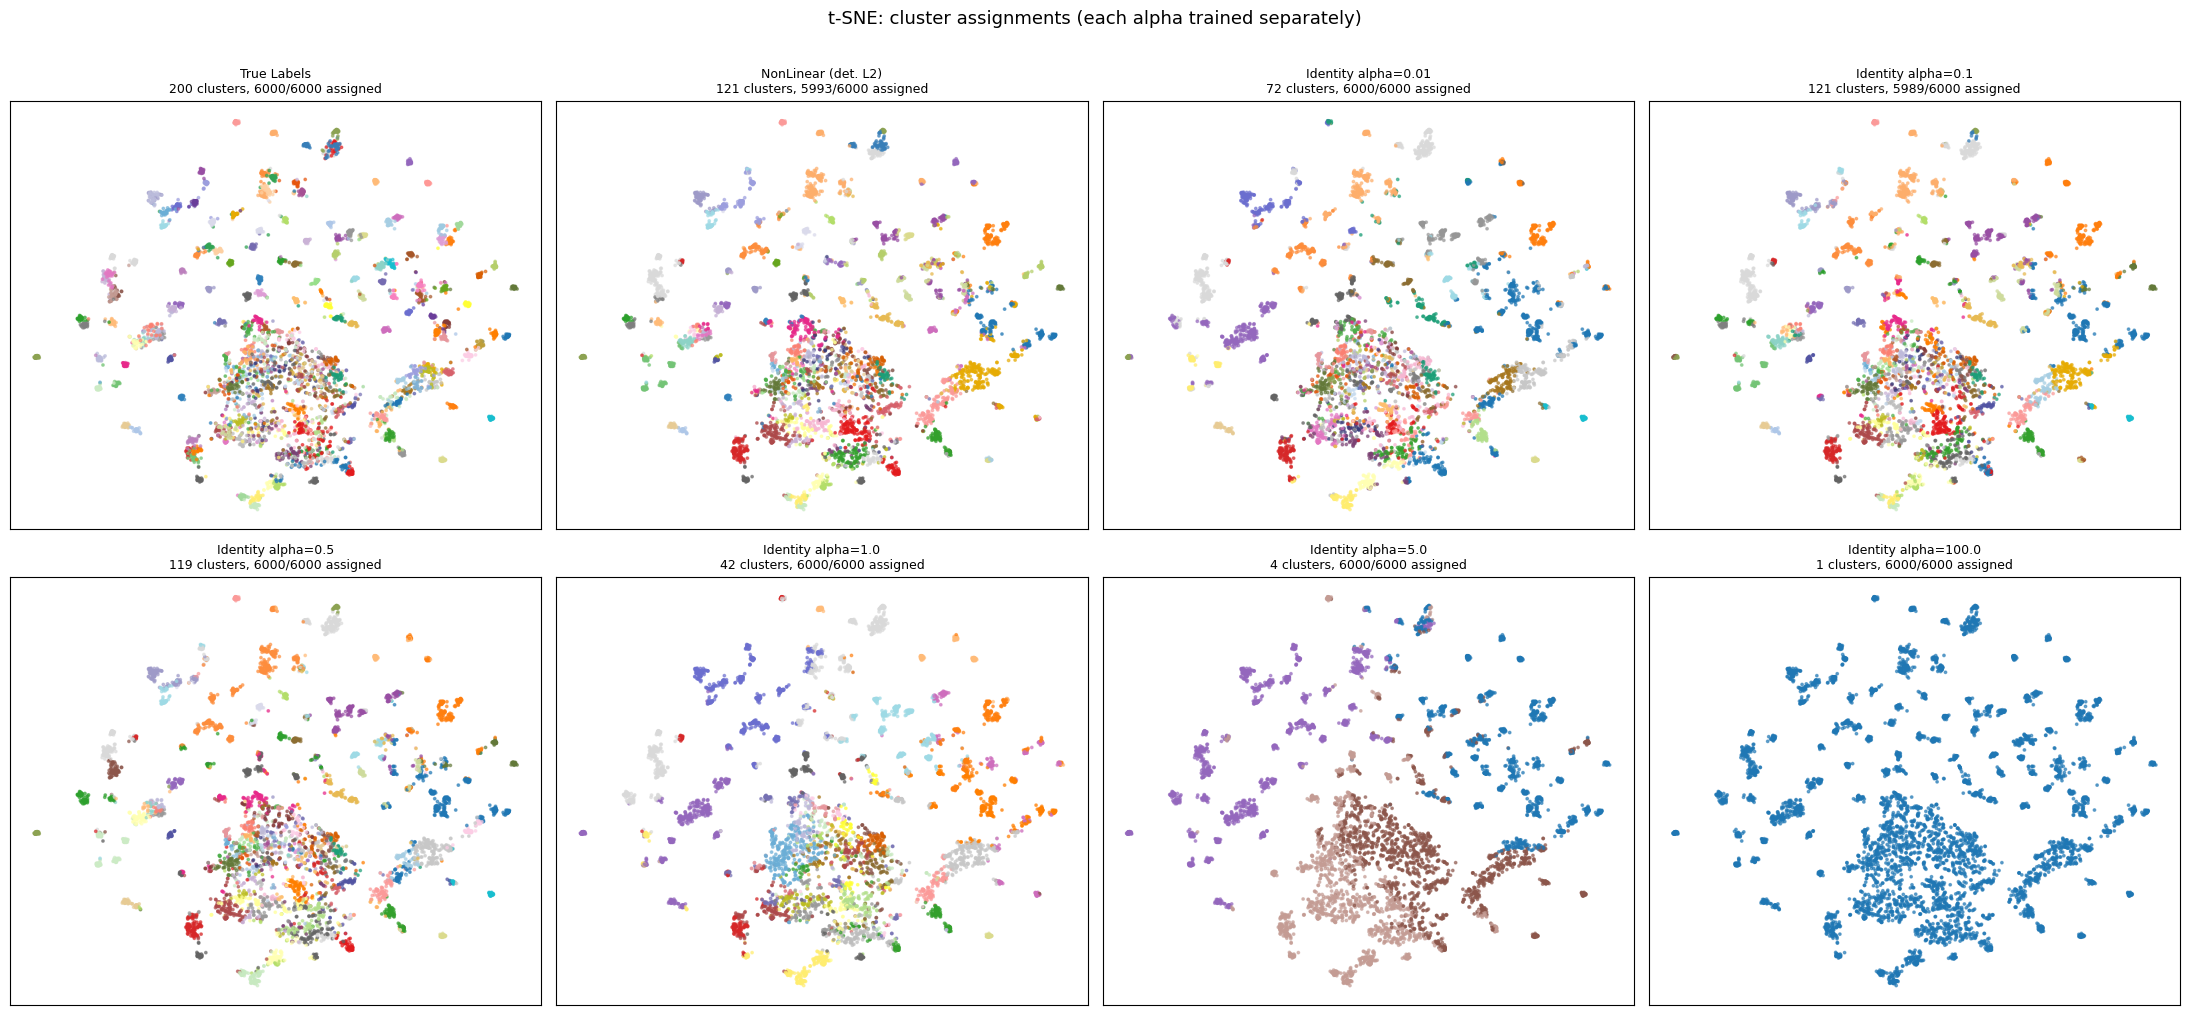

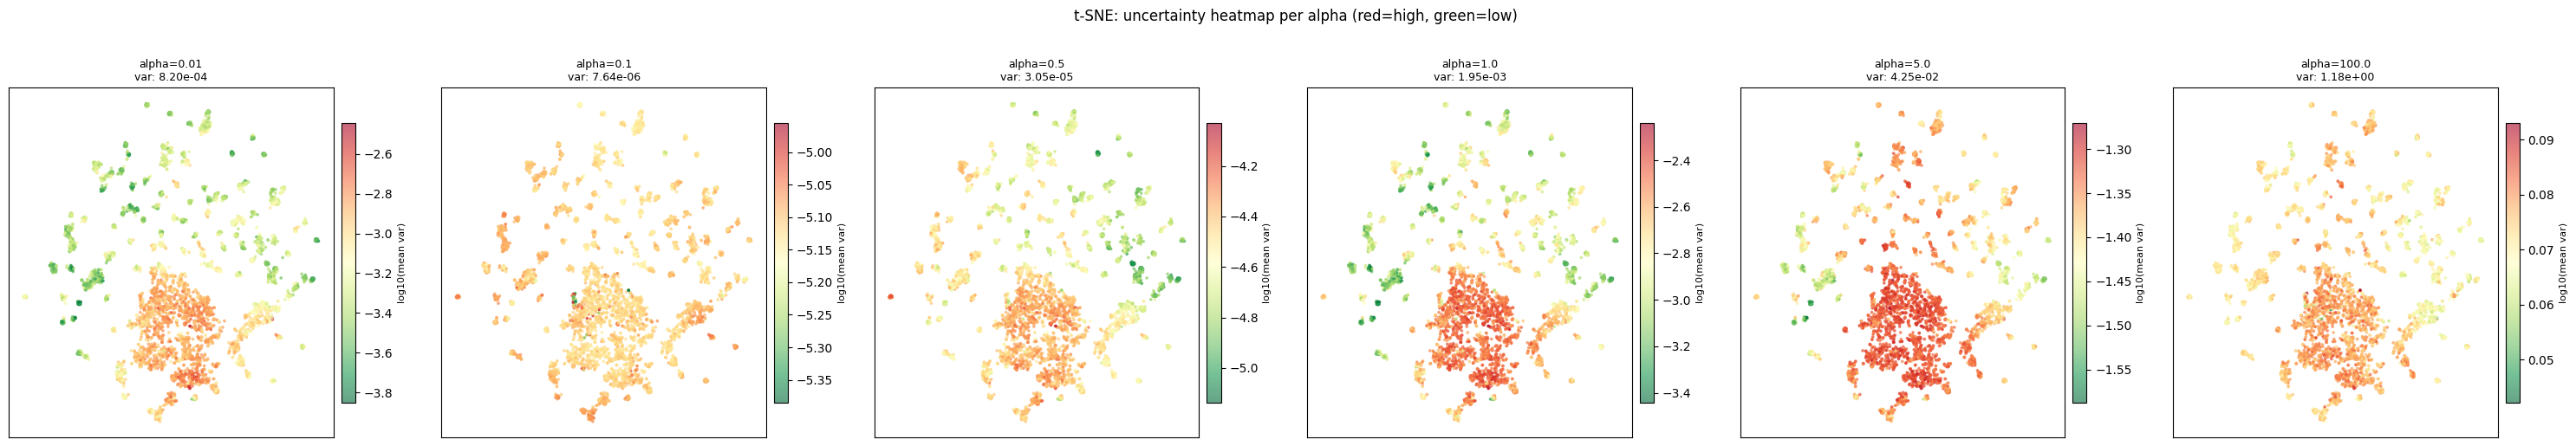

In [15]:
from sklearn.manifold import TSNE

print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(test_emb_nl.mean)
print(f"t-SNE done: {coords.shape}")

point_size = 3
point_alpha = 0.6

true_unique = np.unique(test_labels)
n_true = len(true_unique)
base_colors = np.vstack([
    plt.cm.tab20(np.linspace(0, 1, 20)),
    plt.cm.tab20b(np.linspace(0, 1, 20)),
    plt.cm.tab20c(np.linspace(0, 1, 20)),
    plt.cm.Set1(np.linspace(0, 1, 9)),
    plt.cm.Set3(np.linspace(0, 1, 12)),
    plt.cm.Dark2(np.linspace(0, 1, 8)),
    plt.cm.Paired(np.linspace(0, 1, 12)),
])
species_colors = np.tile(base_colors, (max(1, n_true // len(base_colors) + 1), 1))[:n_true]
true_label_to_color = {lab: species_colors[i] for i, lab in enumerate(true_unique)}

def plot_clusters(ax, coords, labels, title, alignment=None):
    mask_on = labels != -1
    mask_off = ~mask_on
    if mask_off.any():
        ax.scatter(coords[mask_off, 0], coords[mask_off, 1],
                   c="lightgray", s=point_size, alpha=0.3, rasterized=True)
    if mask_on.any():
        if alignment is not None:
            mapped = np.array([alignment.get(l, -1) for l in labels[mask_on]])
            c = np.array([true_label_to_color.get(m, [0.7,0.7,0.7,1.0]) for m in mapped])
        else:
            c = np.array([true_label_to_color[l] for l in labels[mask_on]])
        ax.scatter(coords[mask_on, 0], coords[mask_on, 1],
                   c=c, s=point_size, alpha=point_alpha, rasterized=True)
    n_c = len(np.unique(labels[mask_on])) if mask_on.any() else 0
    n_a = int(mask_on.sum())
    ax.set_title(f"{title}\n{n_c} clusters, {n_a}/{len(labels)} assigned", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

def get_alignment(true_labels, pred_labels):
    mask = pred_labels != -1
    if mask.sum() < 2: return {}
    return align_labels_via_hungarian_algorithm(true_labels[mask], pred_labels[mask])

tsne_alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 100.0]
n_plots = len(tsne_alphas) + 2  # true labels + nonlinear + alphas
ncols = 4
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 5))
axes_flat = axes.flatten()

plot_clusters(axes_flat[0], coords, test_labels, "True Labels")

align_nl = get_alignment(test_labels, pred_nl)
plot_clusters(axes_flat[1], coords, pred_nl, f"NonLinear (det. L2)", alignment=align_nl)

for i, alpha in enumerate(tsne_alphas):
    pred = sweep_results[alpha]['pred']
    alignment = get_alignment(test_labels, pred)
    plot_clusters(axes_flat[i + 2], coords, pred,
                  f"Identity alpha={alpha}", alignment=alignment)

for j in range(len(tsne_alphas) + 2, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle("t-SNE: cluster assignments (each alpha trained separately)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Uncertainty heatmaps ---
fig, axes = plt.subplots(1, len(tsne_alphas), figsize=(len(tsne_alphas) * 5, 5))

for ax, alpha in zip(axes, tsne_alphas):
    unc = sweep_results[alpha]['test_emb'].variance.mean(axis=1)
    log_unc = np.log10(unc + 1e-12)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=log_unc, s=3, alpha=0.6,
                    cmap="RdYlGn_r", rasterized=True)
    cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("log10(mean var)", fontsize=8)
    ax.set_title(f"alpha={alpha}\nvar: {unc.mean():.2e}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("t-SNE: uncertainty heatmap per alpha (red=high, green=low)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Summary

Each $\alpha$ value produces a **different variance network** because the identity form
loss gradient has a threshold $\delta_d^2 > v_d + \alpha$ that controls which dimensions
develop high variance. Key observations:

**Training:**
- Small $\alpha$ $\Rightarrow$ tight regularization $\Rightarrow$ variance stays small (e.g., $\alpha=0.01$: mean var = 0.000820)
- Large $\alpha$ $\Rightarrow$ weak gradient signal $\Rightarrow$ variance grows freely $\Rightarrow$ large learned $\sigma^2$ (e.g., $\alpha=100$: mean var = 1.185)
- The relationship is non-monotonic (U-shaped): variance first decreases from $\alpha=0.01$ to $\alpha=0.1$, then increases dramatically

**Clustering:**
- The identity form similarity with small $\alpha$ is dominated by the log-normalizer term,
  which compresses the similarity distribution and degrades cluster separability
- Large $\alpha$ causes catastrophic clustering collapse: variance grows so large that the
  similarity distribution compresses to near-uniform, yielding $k=1$--$3$ clusters with F1>0.5 = 0.
  This is the opposite of convergence to the deterministic baseline ($k=121$, F1>0.5 = 40).
- The sweet spot is $\approx 0.1$--$0.5$, where variance is minimal and clustering
  quality approaches (but does not exceed) the deterministic NonLinear baseline

**Selective prediction:**
- The $\alpha$ that produces the most dynamic range in variance (neither collapsed to zero
  nor uniformly large) should give the best uncertainty ranking for selective prediction
- However, the data shows that no $\alpha$ provides a strong selective prediction signal;
  all variants improve only marginally over the random baseline
- The optimal $\alpha$ for selective prediction ($\alpha = 0.01$) differs from the best for clustering ($\approx 0.1$--$0.5$),
  confirming that these two objectives are largely decoupled